# Soil Texture and Structure — Interactive Notebook

**MOOC "The Hydrology of Soil" — Chapter 1**
*Companion to the slides "Texture and Structure of soils" (R. Rigon)*

---

This notebook has **two interactive exercises**:

1. **The texture triangle.** You choose the percentages of sand, silt and clay;
   the notebook returns the **USDA textural class name** and plots the point inside the texture triangle.

2. **The granulometric curve.** You shape a **grain-size distribution curve**
   and the notebook draws it, classifies the soil, and connects the curve to the texture triangle.

The long plotting and slider code is hidden inside the shared `soil_course` package.
Students only need to run short function calls.

Run the cells in order (Shift+Enter).


## 0 — Setup

Run this cell once at the beginning. It installs and imports the shared course package, so the rest of the notebook can use short commands instead of long hidden code.


In [ ]:
try:
    from soil_course import *
    print("soil_course already available")
except ModuleNotFoundError:
    !pip install git+https://github.com/panzerotto/soil_course.git
    from soil_course import *

print("Setup complete")


  Cloning https://github.com/panzerotto/soil_course.git to /tmp/pip-req-build-f2ttyite
  Running command git clone --filter=blob:none --quiet https://github.com/panzerotto/soil_course.git /tmp/pip-req-build-f2ttyite
  Resolved https://github.com/panzerotto/soil_course.git to commit e4d246166c300a95384779080d95c6a43f82efdc
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for soil-course: filename=soil_course-0.1.0-py3-none-any.whl size=7329 sha256=26b056df511b85189ec89765471ac6f32b28c3e525810eb9f07b9292738d2d42
  Stored in directory: /tmp/pip-ephem-wheel-cache-7zo276su/wheels/d1/cc/3a/6e11e3051820dbb8642dabb07e7fbe97d50387e4b7f07545bd
Successfully built soil-course
Setup complete


---
# Part 1 — The USDA texture triangle

A soil is described by three numbers — the **mass percentages of sand, silt and clay** — which must sum to 100 %. The **USDA texture triangle** divides that space into twelve named classes.

The size classes are:

| fraction | diameter |
|----------|----------|
| sand     | 0.05 – 2 mm |
| silt     | 0.002 – 0.05 mm |
| clay     | < 0.002 mm |

Particles larger than 2 mm are *gravel* and are excluded before computing the percentages.

The functions for this part are now hidden inside the course package:

- `usda_texture_class(sand, clay)`
- `plot_texture_triangle(sand, clay)`

Silt is obtained as `silt = 100 - sand - clay`, so two numbers are enough.


In [ ]:
# Quick check: classify one soil sample
usda_texture_class(sand=40, clay=20)


'Loam'

### 1.1 — Drawing the triangle

Use `plot_texture_triangle(sand, clay)` to draw the triangle and mark your point.


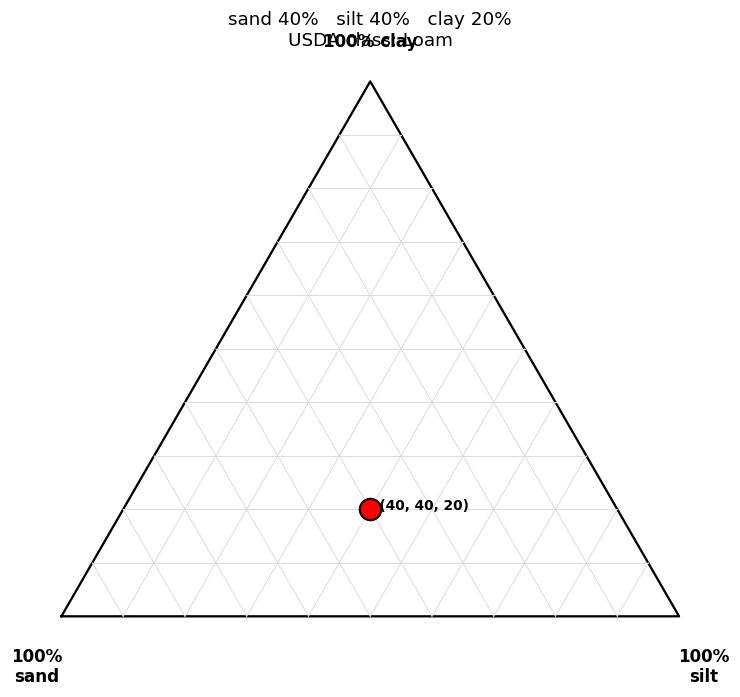

'Loam'

In [ ]:
# Change the sand and clay percentages
plot_texture_triangle(sand=40, clay=20)


### 1.2 — Interactive version (sliders)

Move the **sand** and **clay** sliders. Silt is whatever is left over.

In [ ]:
# Change the sand and clay percentages
interactive_texture_triangle()


interactive(children=(FloatSlider(value=40.0, continuous_update=False, description='sand %', step=1.0), FloatS…

**Try these:**

* `sand = 90, clay = 5`  → a *Sand*
* `sand = 40, clay = 40` → a *Clay*
* `sand = 40, clay = 20` → a *Loam* (the cyan dot on the slide's triangle)
* `sand = 10, clay = 10` → a *Silt loam*
* `sand = 55, clay = 30` → a *Sandy clay loam*

Notice how the **same clay percentage** can give very different class names
depending on the sand/silt balance — clay content alone does not name a soil.


---
# Part 2 — The granulometric (grain-size) curve

The second figure of the slides is the **grain-size distribution curve**:
the *x*-axis is grain diameter on a logarithmic scale, the *y*-axis is the
**percentage of the soil mass finer than that diameter**.

The curve is always **monotonically increasing** from 0 % to 100 %.
Its **position** tells you which fraction dominates (clay / silt / sand /
gravel) and its **steepness** tells you whether the soil is:

* **poorly-graded (uniform)** — a steep curve: most grains have nearly the
  same size;
* **well-graded** — a gentle curve spanning many decades: a broad mixture of
  sizes.

We model the curve with a smooth, adjustable shape so you can explore it.


### 2.1 — A parametric grain-size curve

A convenient model for the percentage-finer curve is the **lognormal cumulative distribution**. In this simplified version, the formula is hidden inside the course package.

You only need to use:

- `percent_finer(d, d50, sigma)`
- `diameter_at_percent(p, d50, sigma)`
- `classify_grain_curve(d50, sigma)`
- `plot_grain_curve(d50, sigma)`

The two key parameters are still:

- **`d50`** — the median grain diameter in mm;
- **`sigma`** — the spread of the grain-size distribution.


In [ ]:
# Example: percentage finer than 0.05 mm for a chosen curve
percent_finer(d=0.05, d50=0.05, sigma=1.2)


np.float64(50.0)

### 2.2 — Classifying the curve

The package calculates:

- clay, silt, sand and gravel percentages;
- the dominant fraction;
- D10, D30 and D60;
- the uniformity coefficient `Cu`;
- the coefficient of curvature `Cc`;
- whether the curve is well-graded or poorly-graded.


In [ ]:
# Example: classify one grain-size curve
info = classify_grain_curve(d50=0.3, sigma=0.6)
info


{'fractions': {'clay': 5.551115123125783e-15,
  'silt': 0.1412035392054034,
  'sand': 99.78041579210615,
  'gravel': 0.07838066868843896},
 'dominant': 'sand',
 'D10': 0.13905249661642125,
 'D30': 0.21901542629334397,
 'D60': 0.34925095638772247,
 'Cu': 2.511648225570069,
 'Cc': 0.9877181079305316,
 'grading': 'poorly-graded (uniform)',
 'name': 'poorly-graded (uniform) sand'}

### 2.3 — Drawing the curve

The long plotting code is now hidden in `plot_grain_curve(d50, sigma)`.


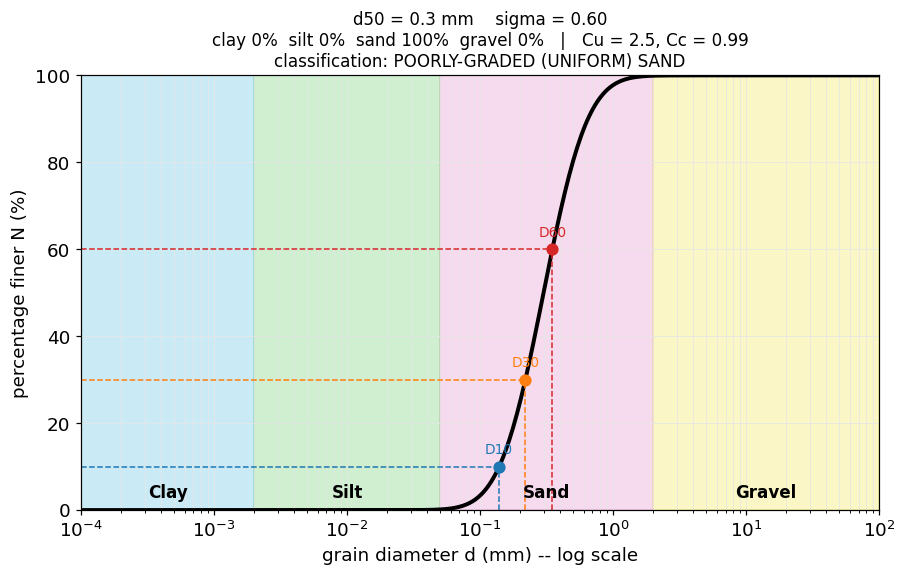

{'fractions': {'clay': 5.551115123125783e-15,
  'silt': 0.1412035392054034,
  'sand': 99.78041579210615,
  'gravel': 0.07838066868843896},
 'dominant': 'sand',
 'D10': 0.13905249661642125,
 'D30': 0.21901542629334397,
 'D60': 0.34925095638772247,
 'Cu': 2.511648225570069,
 'Cc': 0.9877181079305316,
 'grading': 'poorly-graded (uniform)',
 'name': 'poorly-graded (uniform) sand'}

In [ ]:
# Example: change d50 and sigma to explore different soils
plot_grain_curve(d50=0.3, sigma=0.6)


### 2.4 — Interactive version (sliders)

Move the two sliders:

* **`d50`** slides the curve **left** (finer soil) or **right** (coarser soil);
* **`sigma`** makes it **steep** (uniform) or **gentle** (well-graded).


In [ ]:
interactive_grain_curve()


interactive(children=(FloatSlider(value=-0.5228787452803376, continuous_update=False, description='log10 d50',…

**Try these:**

| `d50` (mm) | `sigma` | what you should see |
|-----------|---------|---------------------|
| 0.3  | 0.4 | a **poorly-graded sand** — steep curve sitting in the pink band |
| 0.3  | 1.8 | a **well-graded** soil — gentle curve spanning silt+sand+gravel |
| 0.005 | 0.5 | a **poorly-graded silt** — steep curve in the green band |
| 0.001 | 0.6 | a **clay** — curve in the blue ("Brownian behavior") band |
| 8.0  | 0.5 | a **poorly-graded gravel** — steep curve in the yellow band |

Compare a **steep** curve with a **gentle** one at the same `d50`: same median
size, completely different engineering behaviour. This is exactly the
"poorly graded vs well graded" distinction sketched on slide 8 of the lecture.


---
# Part 3 — Linking the two: from grain sizes to a triangle point

The grain-size curve gives the **sand / silt / clay percentages** (Part 2), and those three numbers place the soil on the **texture triangle** (Part 1).

The package function `curve_to_triangle(d50, sigma)` closes the loop: pick a curve, get its triangle class.

Remember the caveat from the slides: texture is not the whole story. Two soils with identical texture can behave very differently because of **structure** — how the grains pack into aggregates with their own inter-aggregate pores.


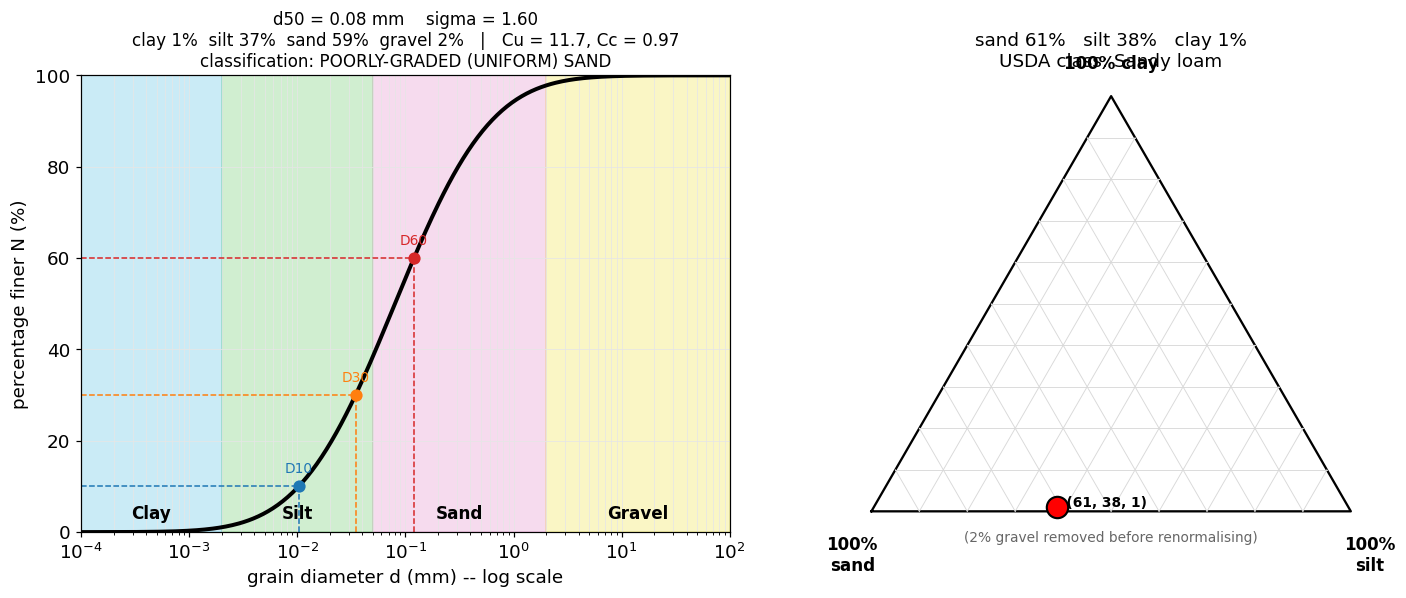

'Sandy loam'

In [ ]:
# Example: grain-size curve on the left, texture triangle on the right
curve_to_triangle(d50=0.08, sigma=1.6)


In [ ]:
interactive_curve_to_triangle()


interactive(children=(FloatSlider(value=-1.0969100130080565, continuous_update=False, description='log10 d50',…

---
## Exercises for students

1. **Find the loam.** Using the Part 1 slider, find three different
   `(sand, clay)` pairs that are all classified as **Loam**. What do they have
   in common?

2. **Clay content is not destiny.** Fix `clay = 30 %`. By changing only the
   sand slider, how many *different* class names can you reach? List them.

3. **Same median, different soil.** In Part 2, keep `d50 = 0.3 mm` and compare
   `sigma = 0.4` with `sigma = 1.8`. Both are "sands" by median size — but read
   off $C_u$. Which one would a geotechnical engineer call well-graded, and why?

4. **The clay corner.** Set `d50 = 0.001 mm` in Part 2. Where does the curve
   sit? On the slide's figure this region is labelled *"Brownian behavior"* —
   explain in one sentence why that label makes physical sense.

5. **Texture is not structure.** Use Part 3 to find a soil classified as
   *Clay*. Then, in your own words, explain why two field samples both
   classified as *Clay* might still drain water at very different rates.
   (Hint: slide 12 — *bimodal pore structure*.)

---

*Notebook prepared as a companion to the MOOC "The Hydrology of Soil",
Chapter 1 — Texture and Structure. Licensed CC BY-SA, consistent with the
lecture slides.*
